# Partially-Observed Planning from Pixels with JaxPlan

In this notebook, we learn a mapping from pixels to RDDL states in Pong and then use this mapping to plan directly from images.
The overall process is:
1. Collect data of (state, image) pairs
2. Train a CNN to map image -> state
3. Use the CNN to map real-time images back to states and do MPC control from these states.

Note: it is highly recommended to run this notebook in an environment with GPU support.

## Learning to Predict RDDL State from Pixels

Install the required packages:

In [ ]:
%pip install --quiet --upgrade pip
%pip install --quiet pyRDDLGym rddlrepository pyRDDLgym-jax

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Next, import the required packages:

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from IPython.display import Image
import os
import PIL
from tqdm import tqdm
import numpy as np
import jax
import jax.numpy as jnp
from flax import linen as nn
import optax

import pyRDDLGym
from pyRDDLGym.core.visualizer.movie import MovieGenerator
from pyRDDLGym_jax.core.planner import JaxBackpropPlanner, JaxOnlineController, load_config_from_string

Now, let's collect some data from a random policy. We concatenate ``obs_t, obs_{t + 1}`` as separate channels to learn the ball velocities:

In [3]:
# resize image, make grayscale and normalize to [0, 1]
def preprocess_frame(img, size=(64, 64)):
    img = img.convert("L").resize(size, PIL.Image.BILINEAR)
    return np.asarray(img, dtype=np.float32) / 255.0

env = pyRDDLGym.make('Pong_arcade', '0', vectorized=True)
env._visualizer._ball_radius *= 2

# collect transitions of (state, obs) pairs: stack previous and current images to obs
n_samples = 2000
states, obss = [], []
while True:
    env.reset()
    prev_obs = preprocess_frame(env.render())[..., None]
    for _ in range(env.horizon):
        action = {'move': np.random.randint(-1, 2)}
        state, _, term, trunc, _ = env.step(action)
        obs = preprocess_frame(env.render())[..., None]
        states.append(np.concatenate([np.reshape(v, (-1,)) for v in state.values()]))
        obss.append(np.concatenate([prev_obs, obs], axis=-1))
        prev_obs = obs
        if term or trunc or np.any(state['ball-x'] > 1) or len(states) >= n_samples: break
    if len(states) >= n_samples: break
env.close()
data = {'states': np.array(states), 'obs': np.array(obss)}

We proceed to train on mini-batches of (state, obs) pairs:

In [4]:
def batch_sampler(data, batch_size=32):
    indices = np.arange(data['states'].shape[0])
    np.random.default_rng().shuffle(indices)
    for i in range(0, len(indices) - batch_size, batch_size):
        idx = indices[i:i+batch_size]
        yield (data['states'][idx], data['obs'][idx])
print(', '.join(str(np.shape(arr)) for arr in next(batch_sampler(data))))

(32, 5), (32, 64, 64, 2)


We will train a convolutional neural network to map image to state:

In [5]:
class PongStateEncoder(nn.Module):
    low = jnp.array([[0., 0., -1., -1., 0.]])
    high = jnp.array([[1., 1., 1., 1., 0.8]])
    
    @nn.compact
    def __call__(self, x):
        x = nn.Conv(16, kernel_size=(3, 3), strides=(2, 2))(x)
        x = nn.relu(x)
        x = nn.Conv(32, kernel_size=(3, 3), strides=(2, 2))(x)
        x = nn.relu(x)
        x = nn.Conv(64, kernel_size=(3, 3), strides=(2, 2))(x)
        x = nn.relu(x)
        x = x.reshape((x.shape[0], -1))
        x = nn.Dense(128)(x)
        x = nn.relu(x)
        x = nn.Dense(5)(x)
        return self.low + (self.high - self.low) * nn.sigmoid(x)
encoder = PongStateEncoder()
encoder_fn = jax.jit(encoder.apply)

We train using ADAM using the MSE between the predicted and actual state for a given image:

In [6]:
optimizer = optax.adam(0.001)
@jax.jit
def update_fn(params, opt_state, obs, state):
    loss, grads = jax.value_and_grad(
        lambda p, o, s: jnp.mean(jnp.square(encoder_fn(p, o) - s)))(params, obs, state)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

Let's now train the CNN:

In [7]:
params = encoder.init(jax.random.PRNGKey(0), jnp.zeros((32, 64, 64, 2)))
opt_state = optimizer.init(params)
for _ in (pbar := tqdm(range(500))):
    ep_loss = 0
    for it, (states, obs) in enumerate(batch_sampler(data)):
        params, opt_state, loss = update_fn(params, opt_state, obs, states)
        ep_loss += float(loss)
    pbar.set_postfix(loss=ep_loss / float(it))

100%|██████████| 500/500 [02:01<00:00,  4.13it/s, loss=1.78e-5] 


## MPC from Pixels with JaxPlan using Trained State Predictor

We train an MPC controller that takes Pong screen images as input, mapes the back to states and computes an optimal action. Let's initialize the controller:

In [8]:
config_str = """
[Compiler]
print_warnings=False
[Planner]
method='JaxStraightLinePlan'
optimizer_kwargs={'learning_rate': 0.01}
batch_size_train=16
batch_size_test=16
rollout_horizon=20
[Optimize]
key=42
epochs=50
"""
planner_args, _, train_args = load_config_from_string(config_str)
planner = JaxBackpropPlanner(rddl=env.model, **planner_args)
agent = JaxOnlineController(planner, print_summary=False, print_progress=False, **train_args)

Finally, we run the controller, first inferring the ground truth RDDL state from consecutive image frames:

Step 0, Pred state: [0.50280267 0.4991081  0.00414813 0.00478196 0.39708975], True state: [0.5  0.5  0.03 0.01 0.4 ]
Step 1, Pred state: [0.5301221  0.5096614  0.03090119 0.01038992 0.39973447], True state: [0.53 0.51 0.03 0.01 0.4 ]
Step 2, Pred state: [0.5592434  0.5185668  0.03155649 0.01006091 0.4005178 ], True state: [0.56 0.52 0.03 0.01 0.4 ]
Step 3, Pred state: [0.59053254 0.5273091  0.03101099 0.00978029 0.44123417], True state: [0.59 0.53 0.03 0.01 0.44]
Step 4, Pred state: [0.6238111  0.539288   0.03151011 0.01029265 0.4392684 ], True state: [0.62 0.54 0.03 0.01 0.44]
Step 5, Pred state: [0.6532244  0.5496735  0.03174639 0.01164579 0.47943026], True state: [0.65 0.55 0.03 0.01 0.48]
Step 6, Pred state: [0.6822842  0.56209505 0.03120911 0.01203501 0.44016916], True state: [0.68 0.56 0.03 0.01 0.44]
Step 7, Pred state: [0.7122234  0.56806004 0.03184211 0.01127172 0.47956058], True state: [0.71 0.57 0.03 0.01 0.48]
Step 8, Pred state: [0.74301356 0.57755446 0.02963471 0.01136708

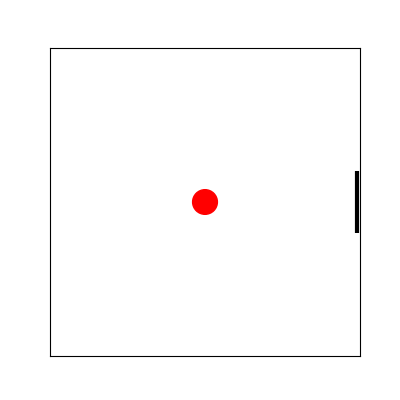

In [9]:
# set visualizer
if not os.path.exists('frames'):
    os.makedirs('frames')
recorder = MovieGenerator("frames", "pong_pomdp", max_frames=100)
env.set_visualizer(viz=None, movie_gen=recorder)

# convert array state to dict
def unflatten_state(state_flat):
    return {'ball-x': state_flat[0:1], 'ball-y': state_flat[1:2], 
            'vel-x': state_flat[2:3], 'vel-y': state_flat[3:4], 'paddle-y': state_flat[4:5]}    

state, _ = env.reset(seed=0)
prev_obs = preprocess_frame(env.render())[..., None]
for step in range(100):

    # predict state from obs
    obs = preprocess_frame(env.render())[..., None]
    encoder_obs = np.concatenate([prev_obs, obs], axis=-1)[None]
    state_flat = np.concatenate([np.reshape(v, (-1,)) for v in state.values()])
    state_pred = encoder_fn(params, encoder_obs).reshape((-1,))
    print(f"Step {step}, Pred state: {state_pred}, True state: {state_flat}")
    
    # use this state to select an action from the mpc controller
    action = agent.sample_action(unflatten_state(state_pred))
    state, *_ = env.step(action)
    prev_obs = obs
env.close()
Image(filename='frames/pong_pomdp_0.gif') 

The policy is near optimal, except missing the last volley, due to imperfections in the learned model. Adding more data and incorporating model robustness could improve the result further.